# Cat Health Agentic RAG with LangChain and LangGraph

In Session 1, retrieval happened before every answer:

```text
question -> retrieve -> generate
```

In this notebook, retrieval becomes a **tool**. The agent can call that tool when it decides the user's question needs cat health guideline context.

That is the core idea of agentic RAG for this session:

```text
question -> agent decides whether to retrieve -> optional retrieval tool call -> answer
```

We will show that loop two ways:

1. **High-level LangChain path**: use `create_agent` with middleware.
2. **Explicit LangGraph path**: build the same loop with `StateGraph`, `ToolNode`, and `tools_condition`.

Both versions use the same retriever tool. The point is to see that agentic RAG is about giving the agent retrieval as an action, not forcing retrieval as a pre-step.

## Learning Outcomes

By the end of this notebook, you will be able to:

- Explain how agentic RAG differs from a fixed two-step RAG pipeline.
- Build and inspect a retrieval tool over a Qdrant vector store.
- Use LangChain middleware to observe and constrain an agent loop.
- Compare the convenience of `create_agent` with the control of an explicit LangGraph graph.
- Design focused routing and middleware experiments for an agentic RAG system.

## Table of Contents

- **Breakout Room #1: High-Level Agentic RAG with LangChain**
  - Task 1: Environment Setup
  - Task 2: Load and Index the Cat Health Corpus
  - Task 3: Create a Retriever Tool
  - Task 4: Build an Agent with `create_agent` and Middleware
  - Task 5: Visualize and Stream the `create_agent` Agent
  - 🏗️ Activity #1: Add a Retriever Tool-Call Budget
- **Breakout Room #2: Explicit Agent Loop with LangGraph**
  - Task 6: Build the Same Agent Loop with LangGraph
  - 🏗️ Activity #2: Add Deterministic Scope Routing
  - 🚧 Advanced Build: Add Explicit Retrieval Quality Control

---
# Breakout Room #1
## High-Level Agentic RAG with LangChain

In this breakout room, you will build the shared retrieval tool, give it to `create_agent`, and use middleware and streaming to inspect and constrain the agent loop.

## Task 1: Environment Setup

From the `02_Agentic_RAG_LangGraph_LangChain` folder, install dependencies with uv:

```bash
uv sync
```

Then open this notebook in Cursor or VS Code and select the Python/Jupyter environment created by uv.

### Imports

LangChain gives us document loading, splitting, embeddings, Qdrant integration, tools, models, and the high-level agent loop.

In [1]:
from pathlib import Path
from getpass import getpass
import os

from IPython.display import Image, display

from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware, ToolCallLimitMiddleware, before_model
from langchain.tools import tool
from langchain_community.document_loaders import TextLoader
from langchain_core.messages import SystemMessage, ToolMessage
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

C:\Users\songz\AppData\Local\Temp\ipykernel_16792\1608185913.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


### API Keys and Models

The chat model and embedding model both use OpenAI. If `OPENAI_API_KEY` is not already set in your environment, this cell will ask for it securely.

LangSmith tracing is optional. If you set `LANGSMITH_TRACING=true` and `LANGSMITH_API_KEY`, LangChain/LangGraph calls will be traced automatically.

In [2]:
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("OpenAI API Key: ")

os.environ.setdefault("LANGSMITH_PROJECT", "aim-session-3-agentic-rag")

chat_model_name = os.environ.get("AIM_CHAT_MODEL", "gpt-5.4-mini")
embedding_model_name = os.environ.get("AIM_EMBEDDING_MODEL", "text-embedding-3-small")

llm = ChatOpenAI(model=chat_model_name)
embeddings = OpenAIEmbeddings(model=embedding_model_name)

print(f"Chat model: {chat_model_name}")
print(f"Embedding model: {embedding_model_name}")
print(f"LangSmith tracing: {os.environ.get('LANGSMITH_TRACING', 'false')}")

Chat model: gpt-5.4-mini
Embedding model: text-embedding-3-small
LangSmith tracing: false


## Task 2: Load and Index the Cat Health Corpus

We will use a small course-owned Markdown corpus instead of a PDF. This keeps the session focused on the agentic RAG pattern instead of PDF parsing.

**Further Reading:**
- [LangChain Retrieval](https://docs.langchain.com/oss/python/langchain/retrieval)
- [Qdrant LangChain Integration](https://qdrant.tech/documentation/frameworks/langchain/)

In [3]:
corpus_path = Path("data/cat_health_guidelines.md")

if not corpus_path.exists():
    raise FileNotFoundError(
        f"Expected the cat health corpus at: {corpus_path.resolve()}\n"
        "Run this notebook from the 02_Agentic_RAG_LangGraph_LangChain folder."
    )

loader = TextLoader(str(corpus_path), encoding="utf-8")
documents = loader.load()

for document in documents:
    document.metadata["source"] = corpus_path.name
    document.metadata["document_type"] = "cat_health_guidelines"

print(f"Loaded {len(documents)} document(s).")
print(documents[0].page_content[:800])
print("\nMetadata:", documents[0].metadata)

Loaded 1 document(s).
# Cat Health Guidelines

This short teaching corpus is for AI Makerspace retrieval exercises. It is not veterinary advice. Students should use it to practice grounding answers in retrieved context and should recommend contacting a veterinarian for medical decisions.

## Preventive Care

Healthy adult cats should have a wellness exam at least once per year. Kittens, senior cats, cats with chronic disease, and cats taking long-term medication may need more frequent visits. A wellness visit may include a weight check, dental exam, vaccine review, parasite prevention review, and discussion of behavior, appetite, hydration, litter box habits, and activity level.

Preventive care is easier when owners track small changes over time. Useful observations include body weight, appetite, drinking, uri

Metadata: {'source': 'cat_health_guidelines.md', 'document_type': 'cat_health_guidelines'}


### Split the Corpus

Chunks should be large enough to keep a useful idea together, but small enough that retrieval returns focused context.

In [4]:
chunk_size = 900
chunk_overlap = 120

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    add_start_index=True,
    separators=["\n## ", "\n### ", "\n\n", "\n", ". ", " "],
)

splits = text_splitter.split_documents(documents)

for index, split in enumerate(splits):
    split.metadata["chunk_id"] = index

print(f"Created {len(splits)} chunks.")
print(splits[0].page_content[:800])
print("\nMetadata:", splits[0].metadata)

Created 10 chunks.
# Cat Health Guidelines

This short teaching corpus is for AI Makerspace retrieval exercises. It is not veterinary advice. Students should use it to practice grounding answers in retrieved context and should recommend contacting a veterinarian for medical decisions.

Metadata: {'source': 'cat_health_guidelines.md', 'document_type': 'cat_health_guidelines', 'start_index': 0, 'chunk_id': 0}


### Build the Qdrant Vector Store

For the course notebook, Qdrant runs in memory. There is no Docker service or cloud account required, and the collection disappears when the notebook kernel stops.

In [5]:
collection_name = "cat_health_agentic_rag"

vector_store = QdrantVectorStore.from_documents(
    documents=splits,
    embedding=embeddings,
    location=":memory:",
    collection_name=collection_name,
)

retrieval_k = 4
print(f"Built in-memory Qdrant collection: {collection_name}")

Built in-memory Qdrant collection: cat_health_agentic_rag


## Task 3: Create a Retriever Tool

This is the important shift from Session 1.

The retriever is no longer a required pre-step. It is now a tool the agent can call when it wants context from the cat health guideline corpus.

The tool name, docstring, inputs, and output format form a contract with the model. Clear contracts make good tool-selection and grounded-answer behavior more likely.

**Further Reading:**
- [LangChain Tools](https://docs.langchain.com/oss/python/langchain/tools)
- [ReAct: Synergizing Reasoning and Acting in Language Models](https://arxiv.org/abs/2210.03629)

In [6]:
def _format_retrieved_docs(scored_docs: list[tuple]) -> str:
    formatted_chunks = []
    for index, (doc, score) in enumerate(scored_docs, start=1):
        source = doc.metadata.get("source", "unknown")
        chunk_id = doc.metadata.get("chunk_id", "unknown")
        start_index = doc.metadata.get("start_index", "unknown")
        score_text = f"{score:.3f}" if isinstance(score, (float, int)) else str(score)
        formatted_chunks.append(
            f"[Source {index}: {source}, chunk_id={chunk_id}, start_index={start_index}, score={score_text}]\n"
            f"{doc.page_content.strip()}"
        )
    return "\n\n".join(formatted_chunks)


@tool
def retrieve_cat_health_guidelines(query: str) -> str:
    """Search the cat health guideline corpus for relevant context about cat preventive care, nutrition, hydration, vaccines, parasites, dental health, urinary warning signs, emergencies, senior cats, stress, behavior, and safe home monitoring."""
    results = vector_store.similarity_search_with_score(query, k=retrieval_k)
    if not results:
        return "No relevant cat health guideline context found."
    return _format_retrieved_docs(results)


retriever_tool = retrieve_cat_health_guidelines

Try the tool directly once. This is just to understand what the agent will see when it calls the tool.

In [7]:
print(
    retriever_tool.invoke(
        {"query": "What urinary signs suggest a cat needs urgent veterinary care?"}
    )[:2500]
)

[Source 1: cat_health_guidelines.md, chunk_id=5, start_index=3071, score=0.673]
## Symptoms That Need Veterinary Attention

Veterinary attention is recommended when a cat has trouble breathing, collapse, seizures, severe weakness, suspected poisoning, trauma, uncontrolled bleeding, repeated vomiting, repeated diarrhea, inability to urinate, straining to urinate, pale gums, severe pain, or a swollen painful abdomen.

Non-emergency changes can still matter. Schedule a veterinary visit for persistent appetite changes, weight loss, increased thirst, increased urination, new hiding, aggression, overgrooming, hair loss, bad breath, drooling, limping, coughing, sneezing that does not improve, or behavior that is unusual for the cat.

[Source 2: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.667]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, diarrhea, or other illness. Owners should pay attention

#### ❓ Question #1

What changes when retrieval becomes a tool instead of a mandatory first step?

##### Answer:

So the agent can decide whether it needs to use the retrieval tool, instead of being forced to search every time. If a question is out of scope or can be answered directly, it avoids unnecessary retrieval, saving both time and computational cost.

## Task 4: Way 1 - Build an Agent with `create_agent` and Middleware

`create_agent` builds the agent loop for us:

1. The model reads the user question and available tools.
2. The model either answers directly or asks to call a tool.
3. If it asks for a tool, LangChain executes the tool.
4. The tool result is added back to the message history.
5. The model continues until it produces a final answer.

This is the fastest way to build agentic RAG: give the agent a retriever tool and let the agent decide when to call it.

Middleware hooks into the loop without requiring us to rebuild the graph. Below, custom `before_model` middleware logs each model step, while built-in middleware limits the number of model calls in one run.

**Further Reading:**
- [LangChain Agents](https://docs.langchain.com/oss/python/langchain/agents)
- [LangChain Middleware](https://docs.langchain.com/oss/python/langchain/middleware)

In [8]:
AGENT_SYSTEM_PROMPT = """You are a cat health guideline assistant in an agentic RAG lesson.

You have one retrieval tool: retrieve_cat_health_guidelines.

Use the retrieval tool when the user asks about cat health, cat symptoms, preventive care, nutrition, vaccines, parasites, dental health, urinary signs, senior cats, stress, behavior, or home monitoring.

When you use retrieved context:
- Answer only from that retrieved context.
- Include a short Sources line using the source labels returned by the tool.
- Remind the user to contact a veterinarian for medical decisions, urgent symptoms, or worsening symptoms.

If the user asks something unrelated to cat health, do not call the tool. Briefly say this notebook is scoped to the cat health guideline corpus.
If the retrieved context does not contain enough information, say you do not have enough information in the cat health guidelines to answer.
"""


@before_model
def log_before_model(state, runtime):
    """Log a compact view of each model step in the agent loop."""
    print(f"[middleware] Calling the model with {len(state['messages'])} message(s).")


agent_middleware = [
    log_before_model,
    ModelCallLimitMiddleware(run_limit=4, exit_behavior="end"),
]


agent = create_agent(
    model=llm,
    tools=[retriever_tool],
    system_prompt=AGENT_SYSTEM_PROMPT,
    middleware=agent_middleware,
)

print(type(agent))

<class 'langgraph.graph.state.CompiledStateGraph'>


#### ❓ Question #2

What does middleware let us change or observe without rebuilding the agent loop? Why is a model-call limit useful?

##### Answer:
Middleware lets us intervene in the agent loop externally without changing the core reasoning logic. That means we can observe or modify things like prompts, tool calls, retrieved context, outputs, and even intermediate steps (e.g., logging, filtering, rewriting, or blocking requests) while keeping the underlying agent architecture unchanged.

A model-call limit is useful because it prevents uncontrolled multi-step loops where the agent keeps calling the model or tools repeatedly. It improves reliability and cost control by capping reasoning depth, avoiding infinite loops, and forcing the system to converge to an answer within bounded compute.

## Task 5: Visualize and Stream the `create_agent` Agent

`create_agent` returns a compiled LangGraph graph. We can visualize that graph and stream updates to inspect when the retriever tool was called.

The exact generated graph includes middleware nodes, but its core loop is:

```text
START -> before-model middleware -> model -> after-model middleware -> END
                                                |
                                                | tool call
                                                v
                                              tools
                                                |
                                                +----> loop back to before-model middleware
```

**Further Reading:**
- [LangGraph Streaming](https://docs.langchain.com/oss/python/langgraph/streaming)
- [LangSmith Observability](https://docs.langchain.com/langsmith/observability)

### Visualize the `create_agent` Graph

Run the next cell to render the exact compiled graph, including middleware nodes. If Mermaid PNG rendering is unavailable in your environment, the fallback prints the Mermaid source.

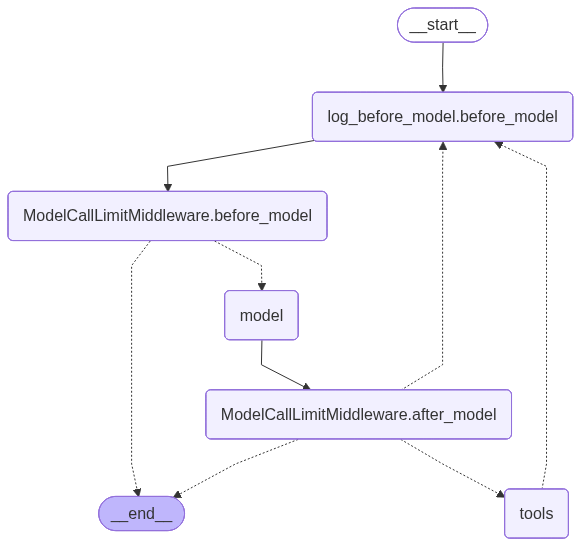

In [9]:
try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(agent.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")

### Stream Agent Runs

Streaming updates lets us inspect the path the agent took. Look for tool messages to see when retrieval happened.

In [10]:
def print_agent_stream(question: str):
    """Run the agent and print each graph update."""
    inputs = {"messages": [{"role": "user", "content": question}]}

    for chunk in agent.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            if update is None:
                print("No state update returned.")
                continue

            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue

            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:1200]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)

### Example 1: Cat Health Question

This should call the retrieval tool before answering.

In [11]:
print_agent_stream("What urinary signs suggest my cat needs urgent veterinary care?")

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_vE8sFUGPmZJBpU0mTkx7IxMB)
 Call ID: call_vE8sFUGPmZJBpU0mTkx7IxMB
  Args:
    query: cat urinary signs urgent veterinary care emergency signs straining not urinating blood in urine frequent litter box trips pain vocalizing

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.731]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, diar

### Example 2: Another Cat Health Question

This should also retrieve, but with a different search query.

In [12]:
print_agent_stream("What preventive care should an adult cat get each year?")

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_SH1epJgIidzDJHqYbxxNVHfY)
 Call ID: call_SH1epJgIidzDJHqYbxxNVHfY
  Args:
    query: adult cat annual preventive care yearly checkup vaccines parasite prevention dental care home monitoring nutrition hydration what should an adult cat get each year

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=1, start_index=268, score=0.735]
## Preventive Care

Healthy adult cats should have a wellness exam at least once per year. Kittens, senior 

### Example 3: Unrelated Question

This should not call the retrieval tool.

In [13]:
print_agent_stream("Who won the 2022 FIFA World Cup?")

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================

This notebook is scoped to the cat health guideline corpus, so I can’t answer questions about the 2022 FIFA World Cup.

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}


#### ❓ Question #3

For each example, did the agent call the retrieval tool? Why or why not?

##### Answer:

For example 1 and 2 the agent call the retrieval tool, example 3 agent did not call the retrieval tool. Example 1 and 2, both of the questions are related to cat care, which can find the answer from the corpus. Example 3 question is out-of-scope and the agent correctly rejects it.

## 🏗️ Activity #1: Add a Retriever Tool-Call Budget

Middleware can enforce an operational rule without changing the retriever tool or rebuilding the agent graph. Create a second agent that allows at most **one** call to `retrieve_cat_health_guidelines` per run.

### Requirements

1. Create a `ToolCallLimitMiddleware` instance scoped to `retriever_tool.name` with `run_limit=1` and `exit_behavior="continue"`.
2. Create `budgeted_agent` with the same model, tool, prompt, and existing middleware plus the new retrieval budget.
3. Ask the agent to use separate searches for urinary emergency signs and annual preventive care before summarizing both.
4. Inspect the stream and explain what the middleware allowed or blocked.

**Further Reading:**
- [Built-in Middleware](https://docs.langchain.com/oss/python/langchain/middleware/built-in)

In [21]:
# Activity #1 workspace
retrieval_budget = ToolCallLimitMiddleware(
    tool_name=retriever_tool.name,
    run_limit=1,
    exit_behavior="continue",
)

budgeted_agent = create_agent(
    model=llm,
    tools=[retriever_tool],
    system_prompt=AGENT_SYSTEM_PROMPT,
    middleware=agent_middleware + [retrieval_budget],
)

budget_question = (
    "Use separate searches for urinary emergency signs and annual preventive care, "
    "then summarize both topics in one answer."
)

inputs = {"messages": [{"role": "user", "content": budget_question}]}

for chunk in budgeted_agent.stream(inputs, stream_mode="updates"):
    for node_name, update in chunk.items():
        print(f"\n--- Update from node: {node_name} ---")
        if update is None:
            print("No state update returned.")
            continue

        messages = update.get("messages", [])
        if not messages:
            print(update)
            continue

        latest_message = messages[-1]
        if isinstance(latest_message, ToolMessage):
            print(f"Tool result preview:\n{latest_message.content[:1200]}")
        elif hasattr(latest_message, "pretty_print"):
            latest_message.pretty_print()
        else:
            print(latest_message)

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_pfbx1NAw1sBVP3kZNP0erSlS)
 Call ID: call_pfbx1NAw1sBVP3kZNP0erSlS
  Args:
    query: urinary emergency signs in cats
  retrieve_cat_health_guidelines (call_c0Wj1VvNgbs2rjyfvmUgsgVE)
 Call ID: call_c0Wj1VvNgbs2rjyfvmUgsgVE
  Args:
    query: annual preventive care for cats

--- Update from node: ToolCallLimitMiddleware[retrieve_cat_health_guidelines].after_model ---
Tool result preview:
Tool call limit exceeded. Do not call 'retrieve_cat_health_guidelines' again.

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}

--- Update from node:

### 📝 Activity #1 Notes

- Which retrieval calls did the agent attempt?
- Which call did the middleware allow or block?
- What quality or safety trade-off does this budget introduce?

##### Answer:

1. Which retrieval calls did the agent attempt?
The agent attempted two separate retrieval calls, matching the user's instruction to search for two topics:
- retrieve_cat_health_guidelines("urinary emergency signs in cats")
- retrieve_cat_health_guidelines("annual preventive care for cats")

This can be seen in the model output where it generated two tool calls.

2. Which call did the middleware allow or block?
- The first retrieval call ("urinary emergency signs in cats") was allowed.
- The second retrieval call ("annual preventive care for cats") was blocked.

The evidence is the middleware message: Tool call limit exceeded. Do not call 'retrieve_cat_health_guidelines' again, which appeared immediately after the model attempted both calls.

3. What quality or safety trade-off does this budget introduce?
The retrieval budget reduces cost and prevents excessive tool usage, making the agent more efficient and predictable. It also helps guard against loops where an agent repeatedly calls the same tool.

However, the trade-off is that the agent may not retrieve all relevant information needed to answer a complex query. In this example, only one topic could be retrieved, so the final answer may be incomplete or less accurate for the blocked topic ("annual preventive care for cats").

## Breakout Room #1 Summary

In BOR1, you:

- Turned retrieval into a source-labeled tool the model can choose to call.
- Built a high-level agent loop with `create_agent`.
- Used middleware to observe the loop and constrain model or tool calls.
- Used streaming to inspect retrieval decisions instead of judging only the final answer.

---
# Breakout Room #2
## Explicit Agent Loop with LangGraph

In this breakout room, you will rebuild the same model-tools loop explicitly, then add routing behavior that would require graph-level control.

## Task 6: Way 2 - Build the Same Agent Loop with LangGraph

Now we will build the minimal agent loop ourselves.

This is the same idea as `create_agent`, but expressed directly as a graph:

```text
START -> agent model -------------------------------> END
              |
              | tool call
              v
            tools
              |
              +---------------------> agent model
```

There is still no mandatory pre-retrieval step. Retrieval only happens if the model emits a tool call. Unlike middleware, graph nodes and conditional edges let us change the control flow itself.

**Further Reading:**
- [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)
- [LangGraph Workflows and Agents](https://docs.langchain.com/oss/python/langgraph/workflows-agents)

In [15]:
llm_with_tools = llm.bind_tools([retriever_tool])


def call_model(state: MessagesState):
    """Call the model with tools bound so it can choose whether to retrieve."""
    response = llm_with_tools.invoke(
        [SystemMessage(content=AGENT_SYSTEM_PROMPT)] + state["messages"]
    )
    return {"messages": [response]}


langgraph_builder = StateGraph(MessagesState)
langgraph_builder.add_node("agent", call_model)
langgraph_builder.add_node("tools", ToolNode([retriever_tool], handle_tool_errors=True))

langgraph_builder.add_edge(START, "agent")
langgraph_builder.add_conditional_edges("agent", tools_condition)
langgraph_builder.add_edge("tools", "agent")

langgraph_agent = langgraph_builder.compile()
print("Compiled the explicit LangGraph agent loop.")

Compiled the explicit LangGraph agent loop.


### Visualize the Explicit LangGraph Agent

This graph should look like the core agent loop: model node, tools node, and a conditional route between them.

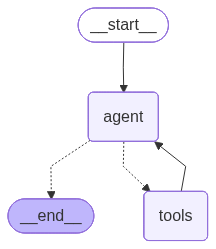

In [16]:
try:
    display(Image(langgraph_agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(langgraph_agent.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")

### Stream the Explicit LangGraph Agent

This helper is intentionally similar to `print_agent_stream`. The difference is that we are streaming from the graph we built ourselves.

In [17]:
def print_langgraph_stream(question: str):
    """Run the explicit LangGraph agent and print each graph update."""
    inputs = {"messages": [{"role": "user", "content": question}]}

    for chunk in langgraph_agent.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue

            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:1200]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)

### Compare the Same Questions

Run the same style of questions through the explicit LangGraph agent. The exact wording may differ, but the retrieval decision should follow the same pattern.

In [18]:
print_langgraph_stream("What urinary signs suggest my cat needs urgent veterinary care?")


--- Update from node: agent ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_63Xlj1c4nsaGIj6eorla4gi0)
 Call ID: call_63Xlj1c4nsaGIj6eorla4gi0
  Args:
    query: urinary signs urgent veterinary care cat warning signs emergency difficulty urinating blood in urine repeated straining litter box

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.766]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, diarrhea, or other illness. Owners should pay attention to straining, frequent trips to the litter box, crying in the box, blood in urine, urinating outside the box, producing very little urine, or not producing urine.

A cat that is straining to urinate, repeatedly visiting the litter box, crying, or producing little or no urine may have a urinary emerge

In [19]:
print_langgraph_stream("Who won the 2022 FIFA World Cup?")


--- Update from node: agent ---
================================== Ai Message ==================================

This notebook is scoped to the cat health guideline corpus, so I can’t help with that question.


#### ❓ Question #4

What parts did `create_agent` hide that the explicit LangGraph version made visible? When would you choose middleware, and when would you change the graph itself?

##### Answer:

`create_agent` hides the implementation details of the agent loop, including graph structure, routing logic, state management, and tool execution. In the explicit LangGraph version, these components become visible: you can see the nodes and edges, how the graph decides whether to call a tool or end the conversation, how messages flow through the state, and how tools are executed as separate graph steps. This makes it easier to understand, customize, and control the agent's behavior, while create_agent provides the same functionality behind a simpler interface.

Use middleware when you want to observe, monitor, or slightly modify behavior around existing model or tool calls without changing the agent's workflow. Examples include logging, enforcing model-call limits, tool-call budgets, guardrails, or prompt modifications.

Change the graph itself when you need to alter the agent's execution flow or add new decision paths. Examples include adding an out-of-scope classifier before retrieval, introducing human approval steps, creating multi-agent workflows, or routing different types of requests to different tools.

## 🏗️ Activity #2: Add Deterministic Scope Routing

The base LangGraph sends every question to the model and relies on the model to reject unrelated requests. Add a small deterministic route before the agent so clearly unrelated questions can bypass the model-tools loop.

### Requirements

1. Add an `out_of_scope` node that returns a brief scope message.
2. Add a routing function that sends likely cat-health questions to `agent` and clearly unrelated questions to `out_of_scope`.
3. Build and compile a new graph with the route immediately after `START`.
4. Test at least one cat-health question, one unrelated question, and one ambiguous question.
5. Explain where the deterministic route helps and where it is brittle.

**Further Reading:**
- [LangGraph Conditional Edges](https://docs.langchain.com/oss/python/langgraph/graph-api#conditional-edges)

In [22]:
# Activity #2 workspace
# Define your out_of_scope node, routing function, and routed graph here.
from langchain_core.messages import AIMessage

def out_of_scope(state: MessagesState):
    return {"messages": [AIMessage(content="Your question is out-of-scope. Please ask a cat health related question.")]}

# A simple keyword-based router, can use LLM to decide whether it's out-of-scope as well
def route_question(state: MessagesState):
    user_message = state["messages"][-1].content.lower()

    cat_keywords = ["cat","kitten","feline","litter","urine",
        "urinary","vet","veterinarian","vaccination","vaccines",
        "parasite","health","dental"]

    if any(keyword in user_message for keyword in cat_keywords):
        return "agent"

    return "out_of_scope"

routed_builder = StateGraph(MessagesState)

routed_builder.add_node("agent", call_model)
routed_builder.add_node("tools",ToolNode([retriever_tool], handle_tool_errors=True))
routed_builder.add_node("out_of_scope", out_of_scope)
routed_builder.add_conditional_edges(
    START,
    route_question,
    {
        "agent": "agent",
        "out_of_scope": "out_of_scope"
    }
)

routed_builder.add_conditional_edges("agent", tools_condition)
routed_builder.add_edge("tools", "agent")

routed_graph = routed_builder.compile()

In [23]:
def print_routed_graph_stream(question: str):
    """Run the explicit LangGraph agent and print each graph update."""
    inputs = {"messages": [{"role": "user", "content": question}]}

    for chunk in routed_graph.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue

            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:1200]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)

In [24]:
# cat-health question
print_langgraph_stream("What urinary signs suggest my cat needs urgent veterinary care?")


--- Update from node: agent ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_wEzljEtYSCJhJtPMNQp75rUk)
 Call ID: call_wEzljEtYSCJhJtPMNQp75rUk
  Args:
    query: urinary signs urgent veterinary care cat emergency red flags straining inability to urinate frequent trips blood in urine pain crying low urine output

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.686]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, diarrhea, or other illness. Owners should pay attention to straining, frequent trips to the litter box, crying in the box, blood in urine, urinating outside the box, producing very little urine, or not producing urine.

A cat that is straining to urinate, repeatedly visiting the litter box, crying, or producing little or no urine may h

In [25]:
# unrelated question
print_langgraph_stream("Who won the 2022 FIFA World Cup?")


--- Update from node: agent ---
================================== Ai Message ==================================

This notebook is scoped to the cat health guideline corpus, so I can’t help with that question.


In [27]:
# ambigious question
print_langgraph_stream("How does it work?")


--- Update from node: agent ---
================================== Ai Message ==================================

This notebook is scoped to the cat health guideline corpus. If you mean the retrieval tool or how I answer cat-health questions, I can explain that.

In short:
- You ask a cat health question.
- I search the guideline corpus for relevant information.
- I answer using only that retrieved guidance.
- If the guidelines don’t cover it, I’ll say I don’t have enough information.
- For medical decisions, urgent symptoms, or worsening symptoms, I’ll remind you to contact a veterinarian.

If you want, I can also show an example of how a cat health question gets answered.


### 📝 Activity #2 Notes

- Which questions bypassed the model-tools loop?
- What happened with the ambiguous question?
- What are the cost, latency, and quality trade-offs of this route?

##### Answer:

1. Which questions bypassed the model-tools loop?
- The 2nd and 3rd questions bypassed the model-tools loop because 2nd is out-of-scope question and 3rd is ambigious, the model asked for further clarification.

2. What happened with the ambiguous question?
- The model asked for further clarification.

3. What are the cost, latency, and quality trade-offs of this route?
- A deterministic route before the agent saves cost and latency by rejecting clearly unrelated questions without an LLM call, but it is brittle because it relies on fixed keywords and fails on synonyms, ambiguous phrasing, or evolving scope. The trade-offs are lower cost and faster rejection for out‑of‑scope queries versus the risk of incorrectly rejecting valid ambiguous questions or missing cleverly worded unrelated ones. For best results, keep the router but add a fallback that sends uncertain cases to the agent to preserve quality while still saving resources on obviously irrelevant queries.


## 🚧 Advanced Build (Optional): Add Explicit Retrieval Quality Control

The base assignment shows the minimal agentic RAG loop two ways:

1. `create_agent`
2. explicit LangGraph

If you want more control, extend the explicit LangGraph version with retrieval quality control. Good advanced additions include:

- Add a document relevance grader after retrieval.
- Add a query rewrite node when retrieval is weak.
- Add a loop limit so the agent cannot keep retrying forever.
- Add a deterministic guardrail before answering.

Those are useful production patterns, but they are not required for the core idea of agentic RAG.

---
## Summary

In this session, you:

1. Built a retrieval tool over a Qdrant vector store.
2. Used `create_agent` and middleware for a high-level agentic RAG loop.
3. Streamed agent runs to inspect when retrieval happened.
4. Rebuilt the loop explicitly with LangGraph nodes and conditional edges.
5. Practiced choosing between middleware-level constraints and graph-level routing.

### Key Takeaways

- Agentic RAG makes retrieval an available action instead of a mandatory pre-step.
- Tool contracts and system prompts strongly influence retrieval decisions.
- Middleware is useful for cross-cutting behavior such as logging, limits, retries, and guardrails.
- Explicit graphs are useful when the application needs custom state or control flow.
- Inspecting intermediate events is essential because a plausible final answer can hide a poor agent path.

### Further Reading

- [LangChain Agents](https://docs.langchain.com/oss/python/langchain/agents)
- [LangChain Middleware](https://docs.langchain.com/oss/python/langchain/middleware)
- [LangGraph Overview](https://docs.langchain.com/oss/python/langgraph/overview)
- [LangSmith Observability](https://docs.langchain.com/langsmith/observability)

### Notebook Output Guidance

Keep useful outputs when you submit, especially graph diagrams and representative streamed runs that support your observations. Remove secrets, failed experiments that no longer matter, and excessively noisy output.